# stimRemovalNull Sessions Analysis (ephax Quickstart Style)

This notebook loads recording sessions from `stimRemovalNull` directories and runs the same core analyses as `ephax_quickstart.ipynb`.


In [10]:
%matplotlib inline
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "ephax").exists() and (repo_root.parent / "ephax").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax import RestingActivityDataset, PrepConfig, LayoutGridPlotter, DCTAnalyzer
from ephax.analyzers import IFRAnalyzer
from ephax.analyzers.ifr import IFRConfig
from ephax.analyzers.firing_distance import FiringDistanceAnalyzer
from ephax.analyzers.cofiring_temporal import CofiringTemporalAnalyzer, CofiringTemporalConfig

plt.rcParams["figure.dpi"] = 120
np.random.seed(0)


## Configure Session Loading

Set `WELLS` and `DIVS` explicitly. For now `DIVS` can contain one DIV, but the same loading code supports multiple DIVs later.


In [11]:
WELLS = [0, 1, 2, 3, 4, 5]
DIVS = [12]
DATA_ROOT = repo_root / "ephax/data/stimRemovalNull"
DATA_FILENAME_TEMPLATE = "DIV{div}_240703_data_well{well}_exp_data.npz"

START_SEC = 0.0
END_SEC = 300.0
MIN_AMP = 0.0

TOP_START = 0
TOP_STOP = 300

recording_specs = []
missing_paths = []
for div in DIVS:
    for well in WELLS:
        path = DATA_ROOT / f"well{well}" / DATA_FILENAME_TEMPLATE.format(div=int(div), well=int(well))
        if path.exists():
            recording_specs.append(
                {
                    "path": path,
                    "well": int(well),
                    "div": int(div),
                    "recording_id": f"stimRemovalNull_well{int(well)}_DIV{int(div)}",
                    "culture_id": f"stimRemovalNull_well{int(well)}",
                }
            )
        else:
            missing_paths.append(path)

if not recording_specs:
    raise FileNotFoundError(f"No stimRemovalNull recordings found for WELLS={WELLS}, DIVS={DIVS}")

# Backward-compatible aliases for later labels and optional output filenames.
WELL = int(recording_specs[0]["well"])
DIV = int(recording_specs[0]["div"])
npz_path = recording_specs[0]["path"]
recording_labels = [f"well{spec['well']} DIV{spec['div']}" for spec in recording_specs]

pd.DataFrame(recording_specs)[["recording_id", "culture_id", "well", "div", "path"]]


,recording_id,culture_id,well,div,path
0,stimRemovalNull_well0_DIV12,stimRemovalNull_well0,0,12,/Users/danielrebbin/Documents/GitHub/ephax/eph...
1,stimRemovalNull_well1_DIV12,stimRemovalNull_well1,1,12,/Users/danielrebbin/Documents/GitHub/ephax/eph...
2,stimRemovalNull_well2_DIV12,stimRemovalNull_well2,2,12,/Users/danielrebbin/Documents/GitHub/ephax/eph...
3,stimRemovalNull_well3_DIV12,stimRemovalNull_well3,3,12,/Users/danielrebbin/Documents/GitHub/ephax/eph...
4,stimRemovalNull_well4_DIV12,stimRemovalNull_well4,4,12,/Users/danielrebbin/Documents/GitHub/ephax/eph...
5,stimRemovalNull_well5_DIV12,stimRemovalNull_well5,5,12,/Users/danielrebbin/Documents/GitHub/ephax/eph...


In [12]:
file_info = []
recording_metadata = []
for spec in recording_specs:
    with np.load(spec["path"], allow_pickle=True) as data:
        sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
        frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
        rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0

    start_time = rec_t0 + START_SEC
    end_time = rec_t0 + END_SEC
    file_info.append((str(spec["path"]), start_time, end_time, int(spec["well"])))
    recording_metadata.append(
        {
            **spec,
            "source_path": str(spec["path"]),
            "start_time": float(start_time),
            "end_time": float(end_time),
            "sf_native": float(sf_native),
        }
    )

ds = RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=MIN_AMP)
rec = ds.recordings[0]

recording_summary_rows = []
for rec_idx, (rec_i, meta) in enumerate(zip(ds.recordings, recording_metadata)):
    in_window = (rec_i.spikes["time"] >= rec_i.start_time) & (rec_i.spikes["time"] <= rec_i.end_time)
    duration = float(rec_i.end_time - rec_i.start_time)
    n_spikes = int(np.sum(in_window))
    n_active_electrodes = int(np.unique(rec_i.spikes["electrode"][in_window]).size)
    recording_summary_rows.append(
        {
            "recording_idx": int(rec_idx),
            "recording_id": meta["recording_id"],
            "culture_id": meta["culture_id"],
            "well": int(meta["well"]),
            "div": int(meta["div"]),
            "duration_s": duration,
            "sf": float(rec_i.sf),
            "n_spikes": n_spikes,
            "n_active_electrodes": n_active_electrodes,
            "mean_spike_rate_hz": n_spikes / duration if duration > 0 else np.nan,
        }
    )

recording_summary = pd.DataFrame(recording_summary_rows)
aggregate_by_div = (
    recording_summary
    .groupby("div", as_index=False)
    .agg(
        n_recordings=("recording_idx", "count"),
        n_wells=("well", "nunique"),
        total_spikes=("n_spikes", "sum"),
        mean_spikes_per_recording=("n_spikes", "mean"),
        mean_active_electrodes=("n_active_electrodes", "mean"),
        mean_spike_rate_hz=("mean_spike_rate_hz", "mean"),
    )
)

print(f"Loaded {len(ds.recordings)} recordings across wells={WELLS} and DIVs={DIVS}")
if missing_paths:
    print(f"Missing requested files skipped: {len(missing_paths)}")
display(recording_summary.round(3))
display(aggregate_by_div.round(3))


Loaded 6 recordings across wells=[0, 1, 2, 3, 4, 5] and DIVs=[12]


,recording_idx,recording_id,culture_id,well,div,duration_s,sf,n_spikes,n_active_electrodes,mean_spike_rate_hz
0,0,stimRemovalNull_well0_DIV12,stimRemovalNull_well0,0,12,300.0,10000.0,128982,998,429.940
1,1,stimRemovalNull_well1_DIV12,stimRemovalNull_well1,1,12,300.0,10000.0,108852,1002,362.840
2,2,stimRemovalNull_well2_DIV12,stimRemovalNull_well2,2,12,300.0,10000.0,113779,986,379.263
3,3,stimRemovalNull_well3_DIV12,stimRemovalNull_well3,3,12,300.0,10000.0,112965,1001,376.550
4,4,stimRemovalNull_well4_DIV12,stimRemovalNull_well4,4,12,300.0,10000.0,97514,980,325.047
5,5,stimRemovalNull_well5_DIV12,stimRemovalNull_well5,5,12,300.0,10000.0,112218,994,374.060


,div,n_recordings,n_wells,total_spikes,mean_spikes_per_recording,mean_active_electrodes,mean_spike_rate_hz
0,12,6,6,674310,112385.0,993.5,374.617


## Layout Grid Visualizations

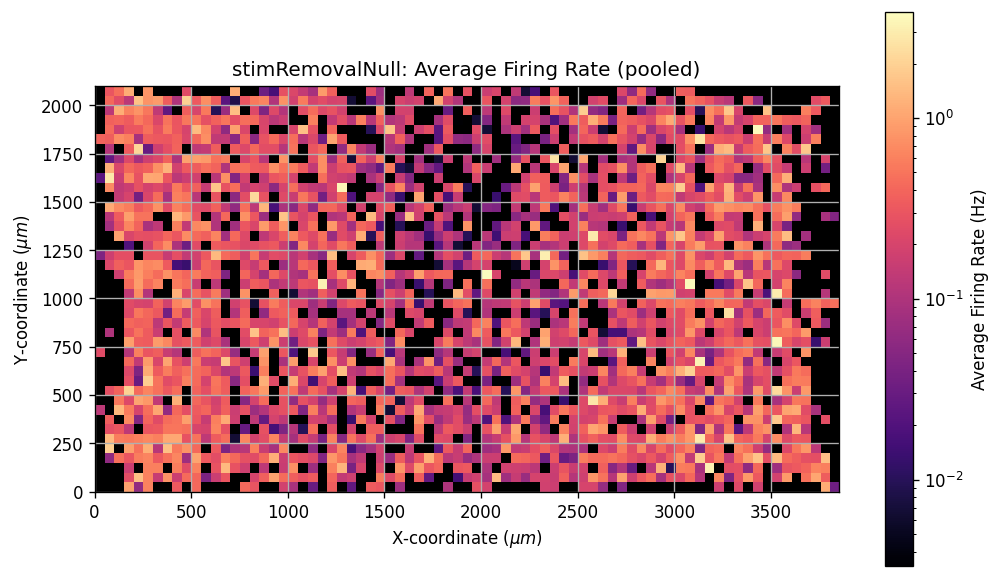

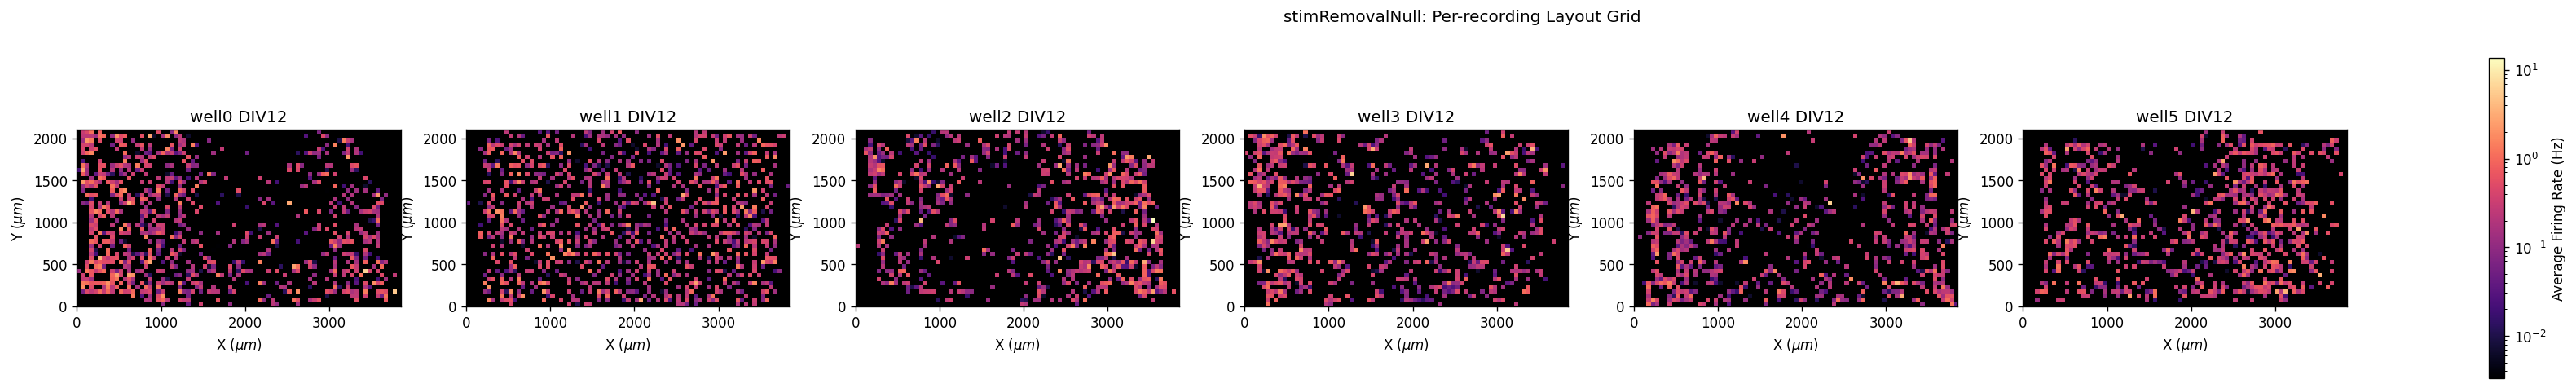

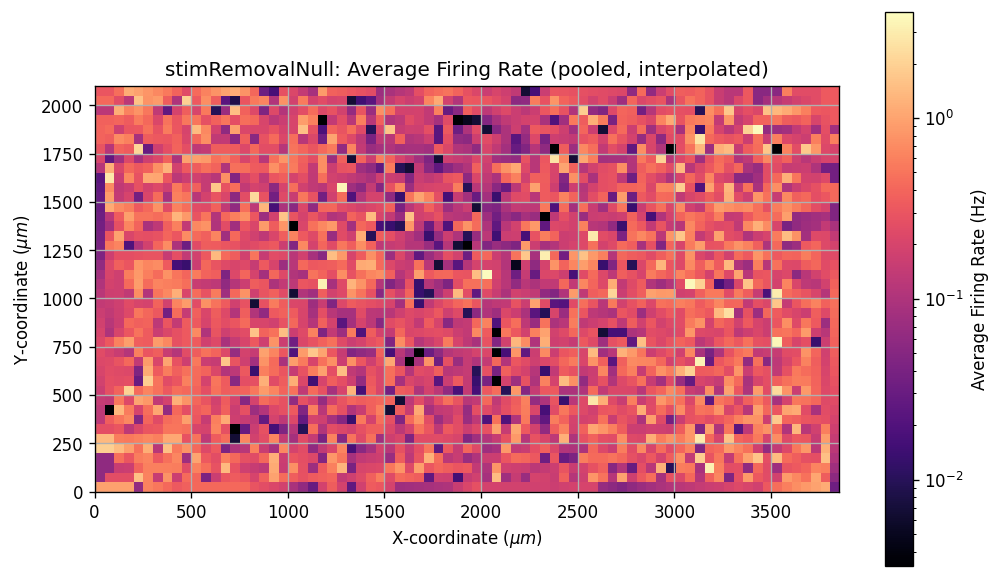

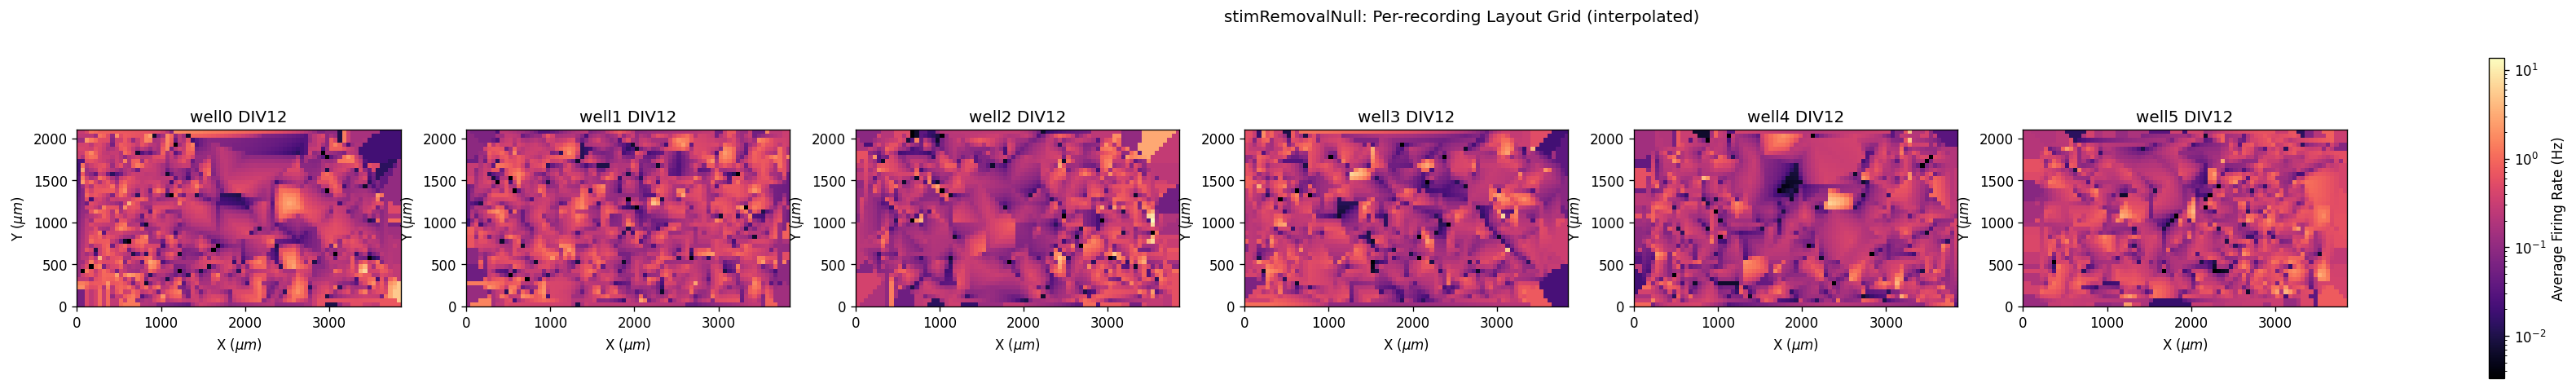

(<Figure size 3600x480 with 7 Axes>,
 array([[<Axes: title={'center': 'well0 DIV12'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>,
         <Axes: title={'center': 'well1 DIV12'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>,
         <Axes: title={'center': 'well2 DIV12'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>,
         <Axes: title={'center': 'well3 DIV12'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>,
         <Axes: title={'center': 'well4 DIV12'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>,
         <Axes: title={'center': 'well5 DIV12'}, xlabel='X ($\\mu m$)', ylabel='Y ($\\mu m$)'>]],
       dtype=object))

In [13]:
lg = LayoutGridPlotter(ds)

# Without interpolation
lg.plot_grid_avghz_pooled(grid_size=50.0, interpolate=False, title="stimRemovalNull: Average Firing Rate (pooled)")
lg.plot_grid_avghz_panel(grid_size=50.0, ncols=6, interpolate=False, title="stimRemovalNull: Per-recording Layout Grid", recording_titles=recording_labels)

# With interpolation
lg.plot_grid_avghz_pooled(grid_size=50.0, interpolate=True, title="stimRemovalNull: Average Firing Rate (pooled, interpolated)")
lg.plot_grid_avghz_panel(grid_size=50.0, ncols=6, interpolate=True, title="stimRemovalNull: Per-recording Layout Grid (interpolated)", recording_titles=recording_labels)


## Select Reference Electrodes

In [14]:
top_stop = 1000
prep_cfg = PrepConfig(mode="top", top_start=0, top_stop=top_stop, verbose=False)
refs_per_recording = ds.select_ref_electrodes(prep_cfg)

for idx, refs in enumerate(refs_per_recording):
    preview = ", ".join(map(str, refs[:5])) + ("..." if refs.size > 5 else "")
    print(f"{recording_labels[idx]}: selected {refs.size} reference electrodes ({preview})")


well0 DIV12: selected 998 reference electrodes (5695, 15325, 25351, 2635, 2177...)
well1 DIV12: selected 1000 reference electrodes (15747, 17087, 779, 3457, 23277...)
well2 DIV12: selected 986 reference electrodes (13181, 10101, 8315, 24149, 7399...)
well3 DIV12: selected 1000 reference electrodes (13597, 20093, 8759, 17113, 22839...)
well4 DIV12: selected 980 reference electrodes (15753, 25047, 3919, 19187, 19767...)
well5 DIV12: selected 994 reference electrodes (14417, 2599, 4821, 13487, 5681...)


## Instantaneous Firing Rate (IFR)

In [15]:
ifr_cfg = IFRConfig(
    log_scale=True,
    overlay_gmm=True,
    time_grid_hz=200.0,
    max_time_points=2_000,
)
ifr_analyzer = IFRAnalyzer.from_dataset(ds, config=ifr_cfg, selection_prep_config=prep_cfg)
peaks = ifr_analyzer.peaks()

print(f"Collected {peaks.values.size} IFR samples")
if peaks.peaks_hz.size:
    print("GMM peak locations (Hz):", np.round(peaks.peaks_hz, 2))
else:
    print("No peaks detected; consider widening the selection window.")


Collected 1336698 IFR samples
GMM peak locations (Hz): [ 0.05  1.31  5.22 36.25]


(<Figure size 1200x720 with 1 Axes>,
 <Axes: title={'center': 'Gaussian Mixture Model Fit to IFR Data'}, xlabel='Log(IFR)', ylabel='Density'>)

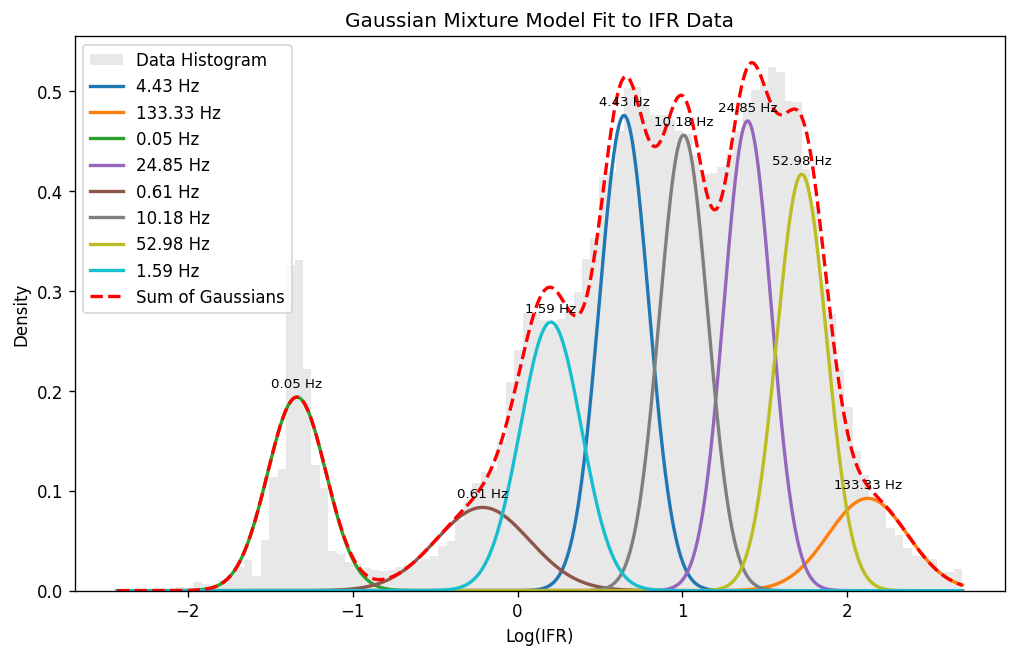

In [16]:
ifr_analyzer.plot_histogram()

[(<Figure size 1440x960 with 3 Axes>,
  (<Axes: title={'center': 'stimRemovalNull | well0 DIV12: Log Instantaneous Firing Rate Across Top 998 electrodes'}, xlabel='Time (s)', ylabel='Channel by Firing Frequency Rank'>,
   <Axes: title={'center': 'Histogram of Instantaneous Firing Rates'}, xlabel='Log Instantaneous Firing Rate (Hz)', ylabel='Frequency'>)),
 (<Figure size 1440x960 with 3 Axes>,
  (<Axes: title={'center': 'stimRemovalNull | well1 DIV12: Log Instantaneous Firing Rate Across Top 1000 electrodes'}, xlabel='Time (s)', ylabel='Channel by Firing Frequency Rank'>,
   <Axes: title={'center': 'Histogram of Instantaneous Firing Rates'}, xlabel='Log Instantaneous Firing Rate (Hz)', ylabel='Frequency'>)),
 (<Figure size 1440x960 with 3 Axes>,
  (<Axes: title={'center': 'stimRemovalNull | well2 DIV12: Log Instantaneous Firing Rate Across Top 986 electrodes'}, xlabel='Time (s)', ylabel='Channel by Firing Frequency Rank'>,
   <Axes: title={'center': 'Histogram of Instantaneous Firing Ra

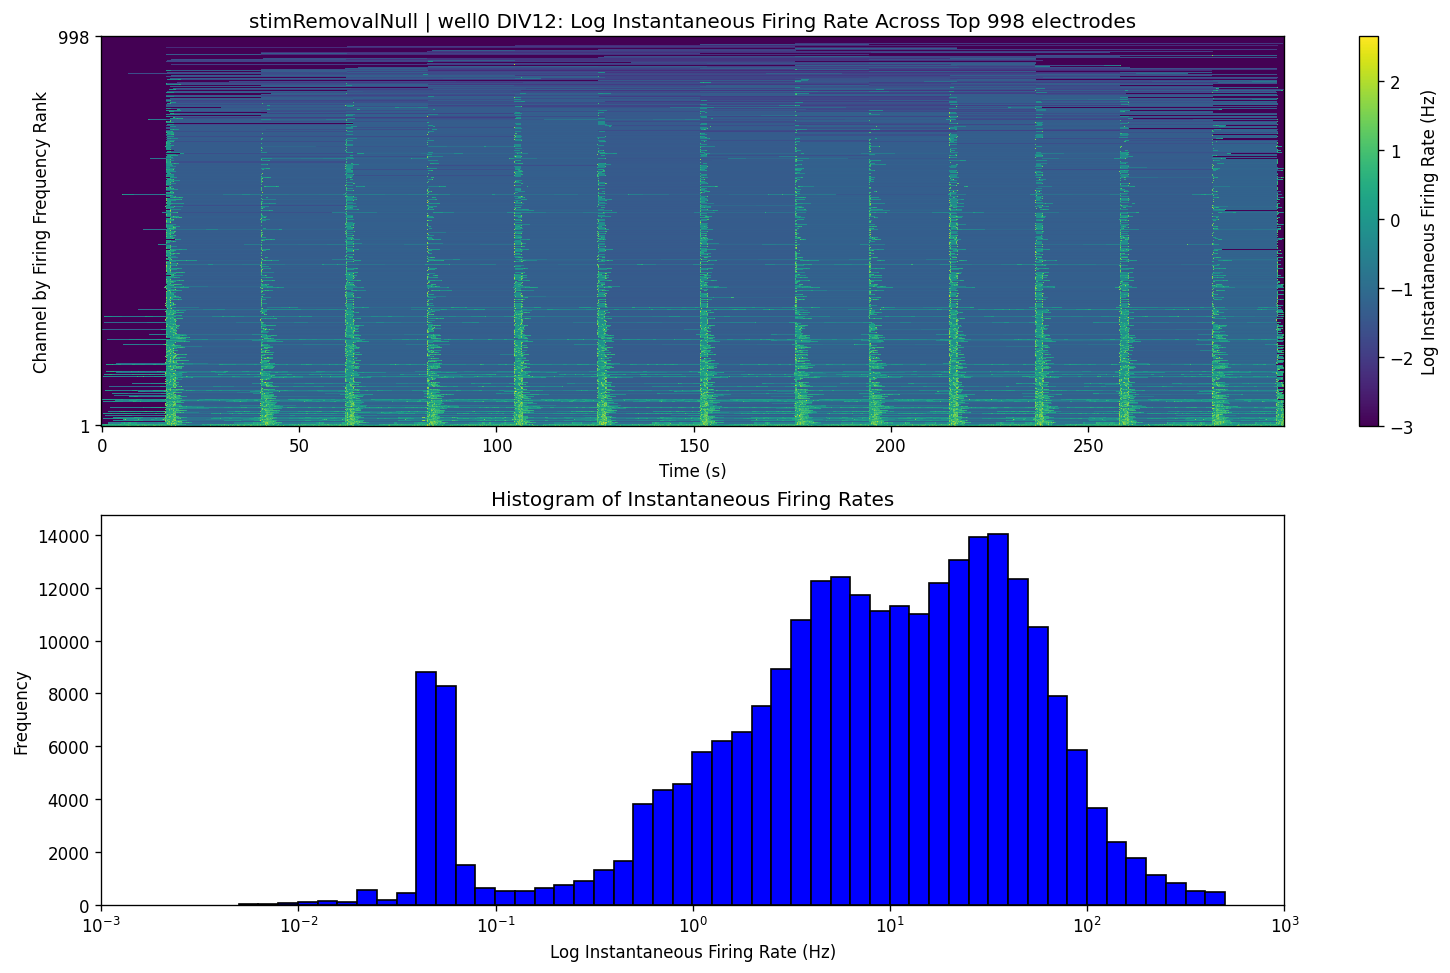

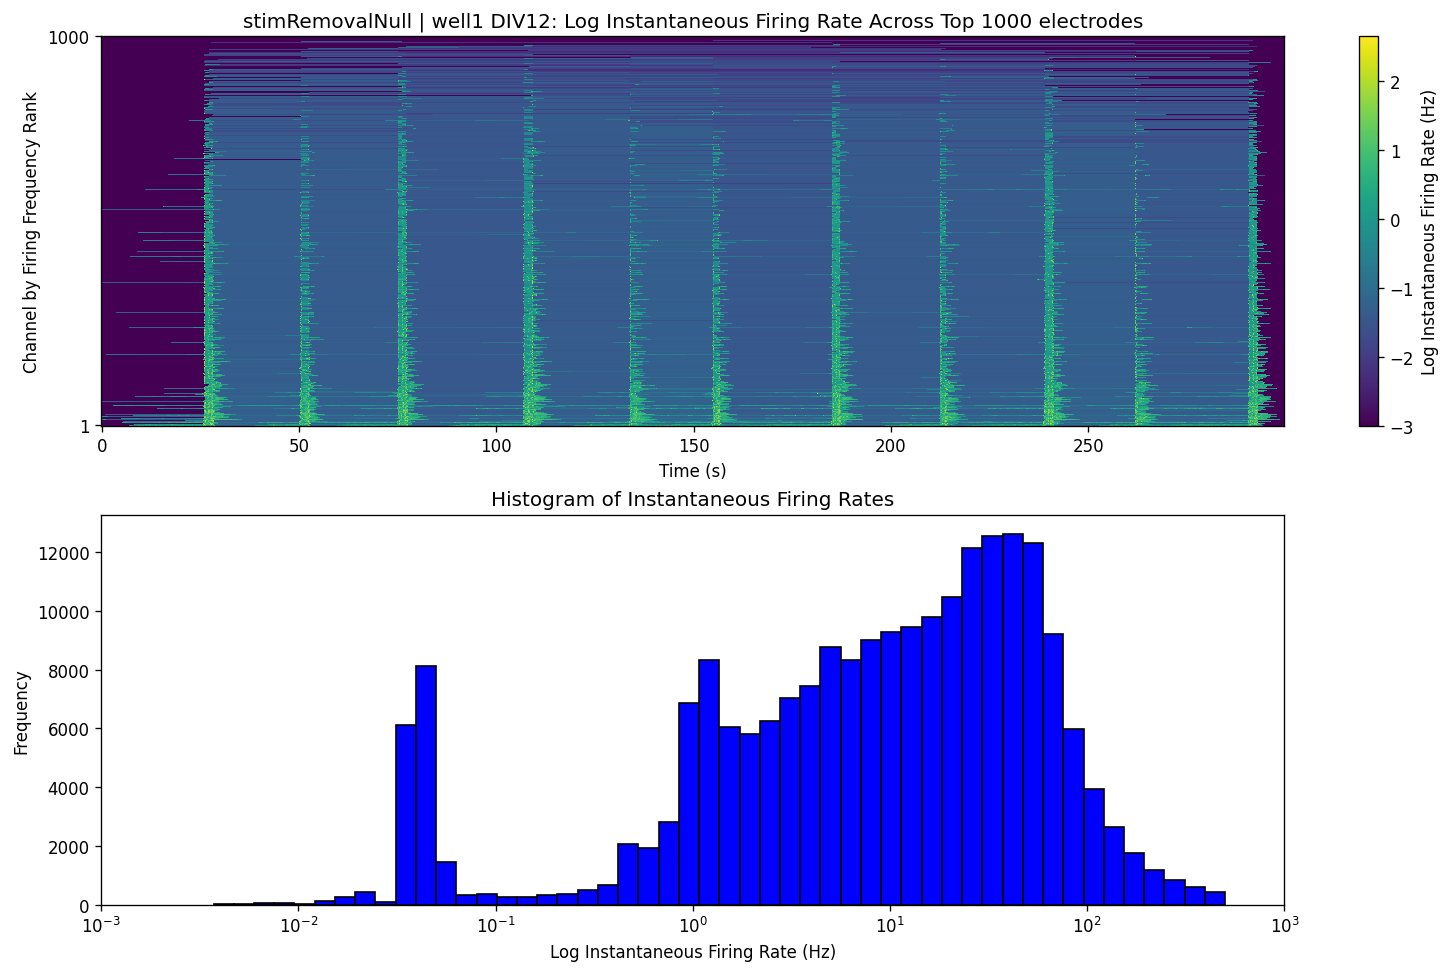

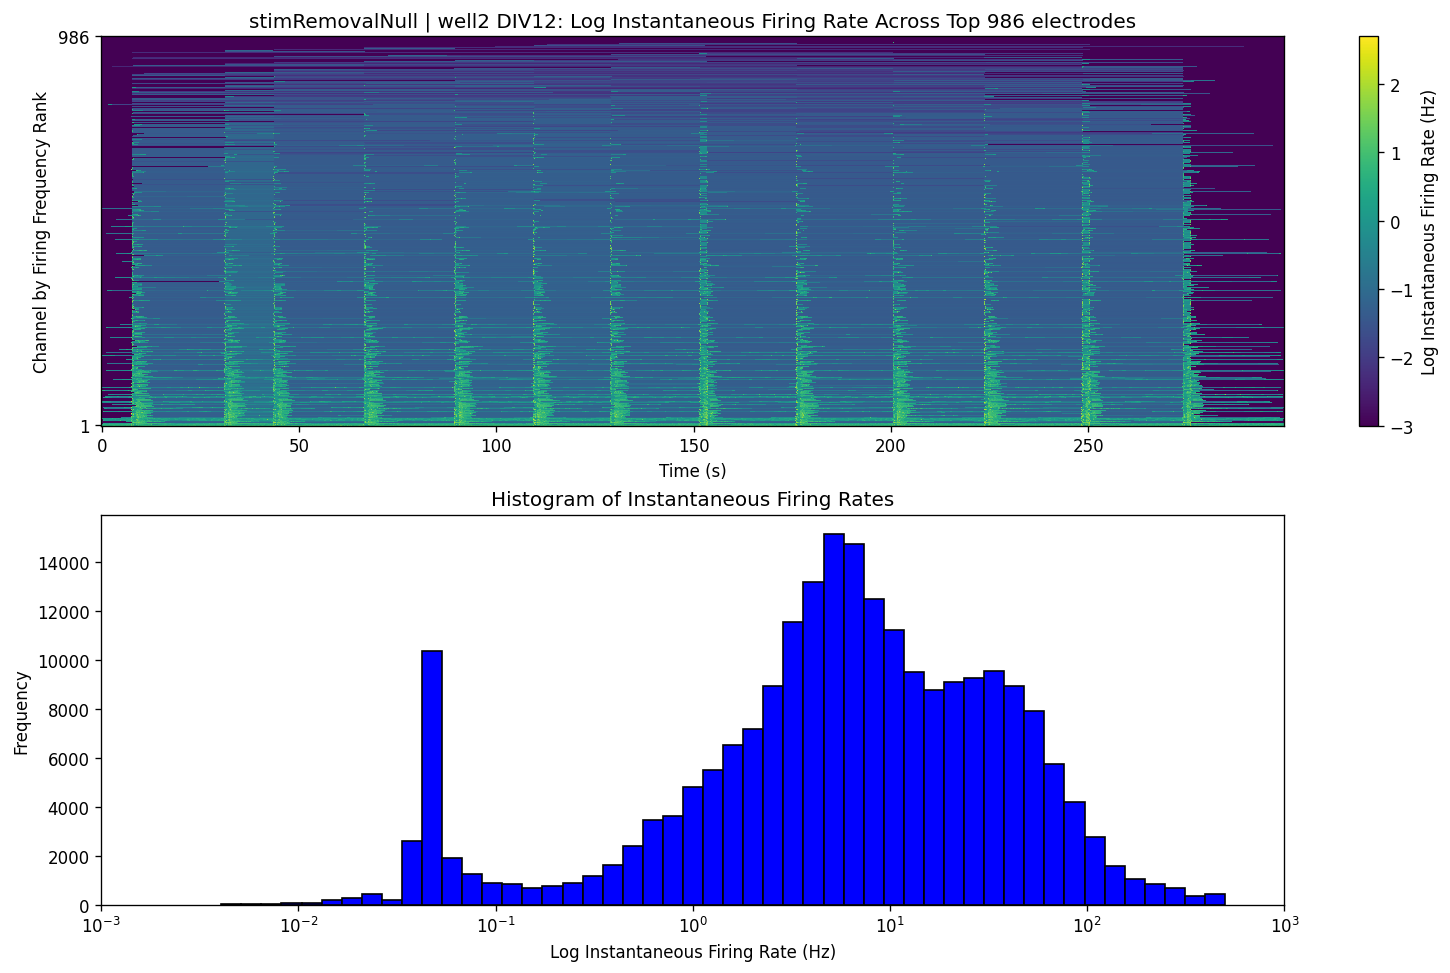

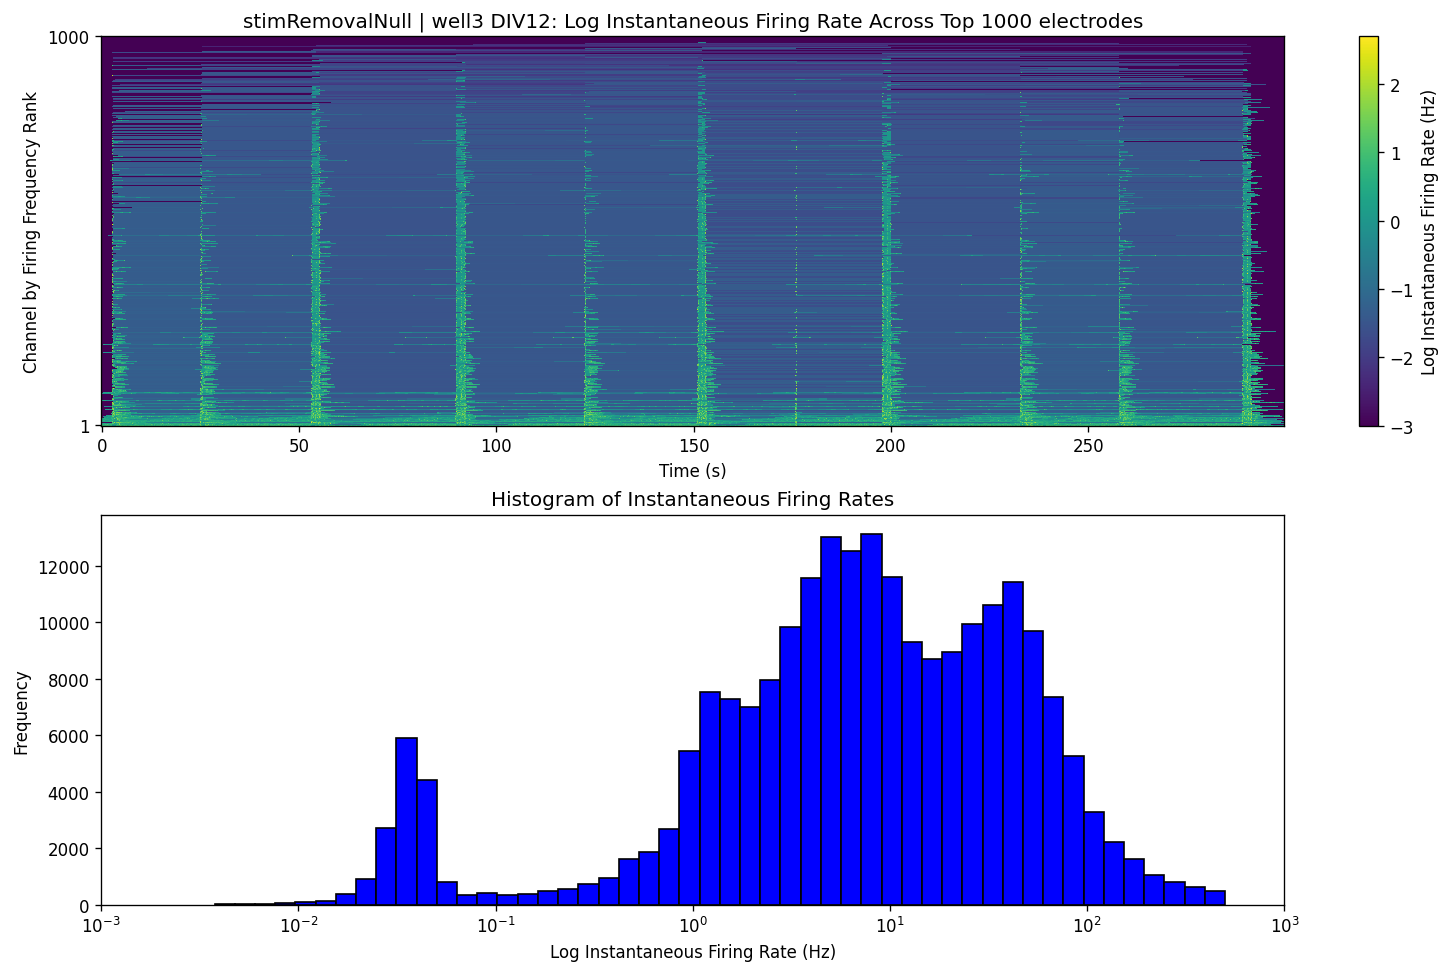

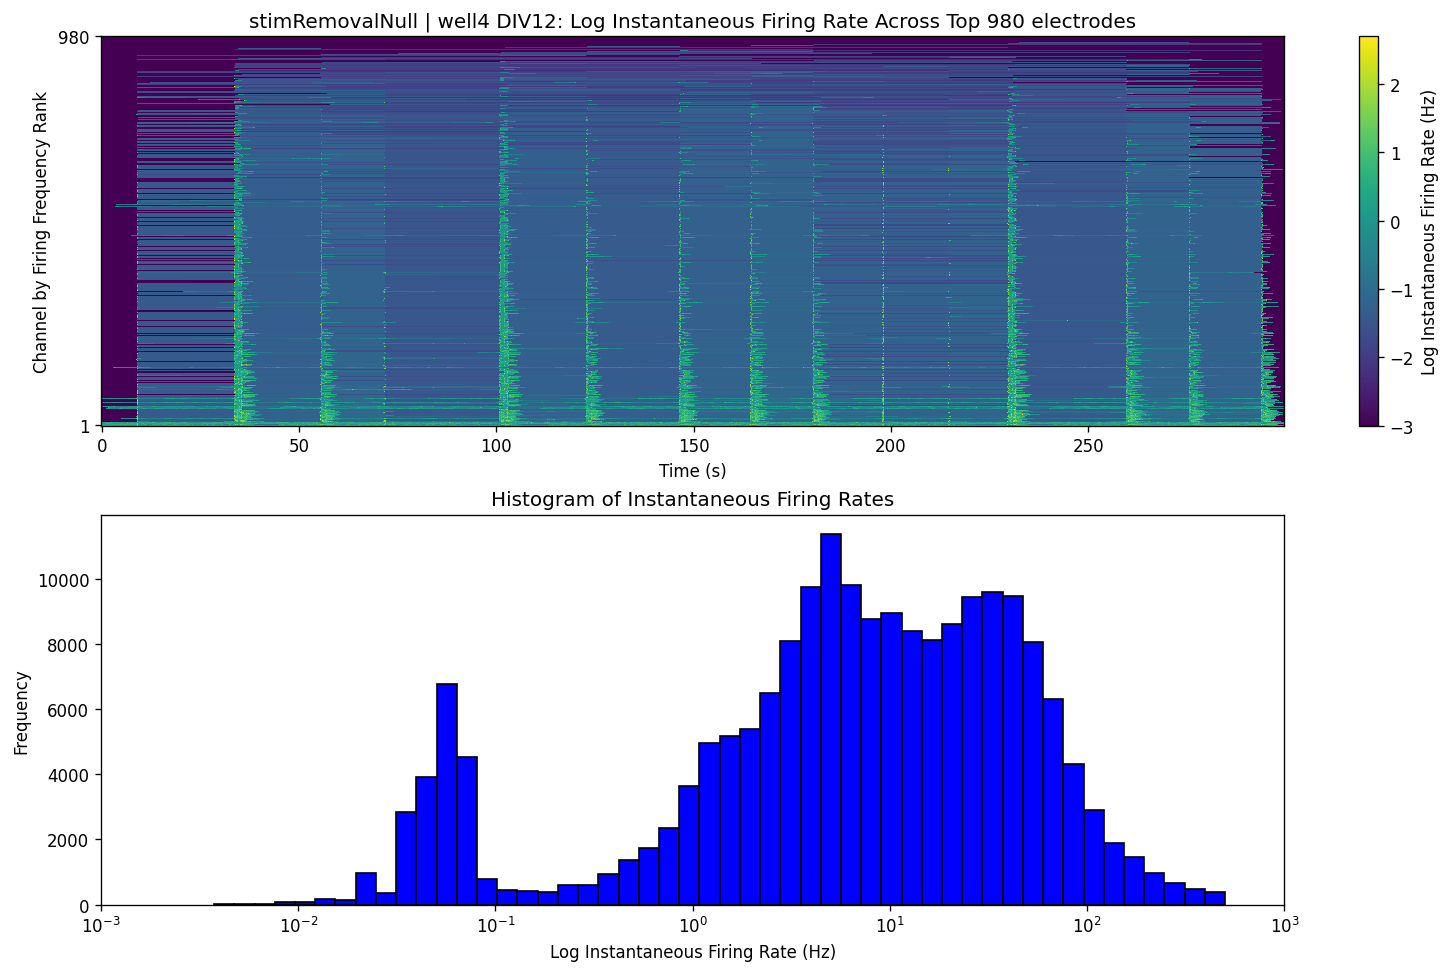

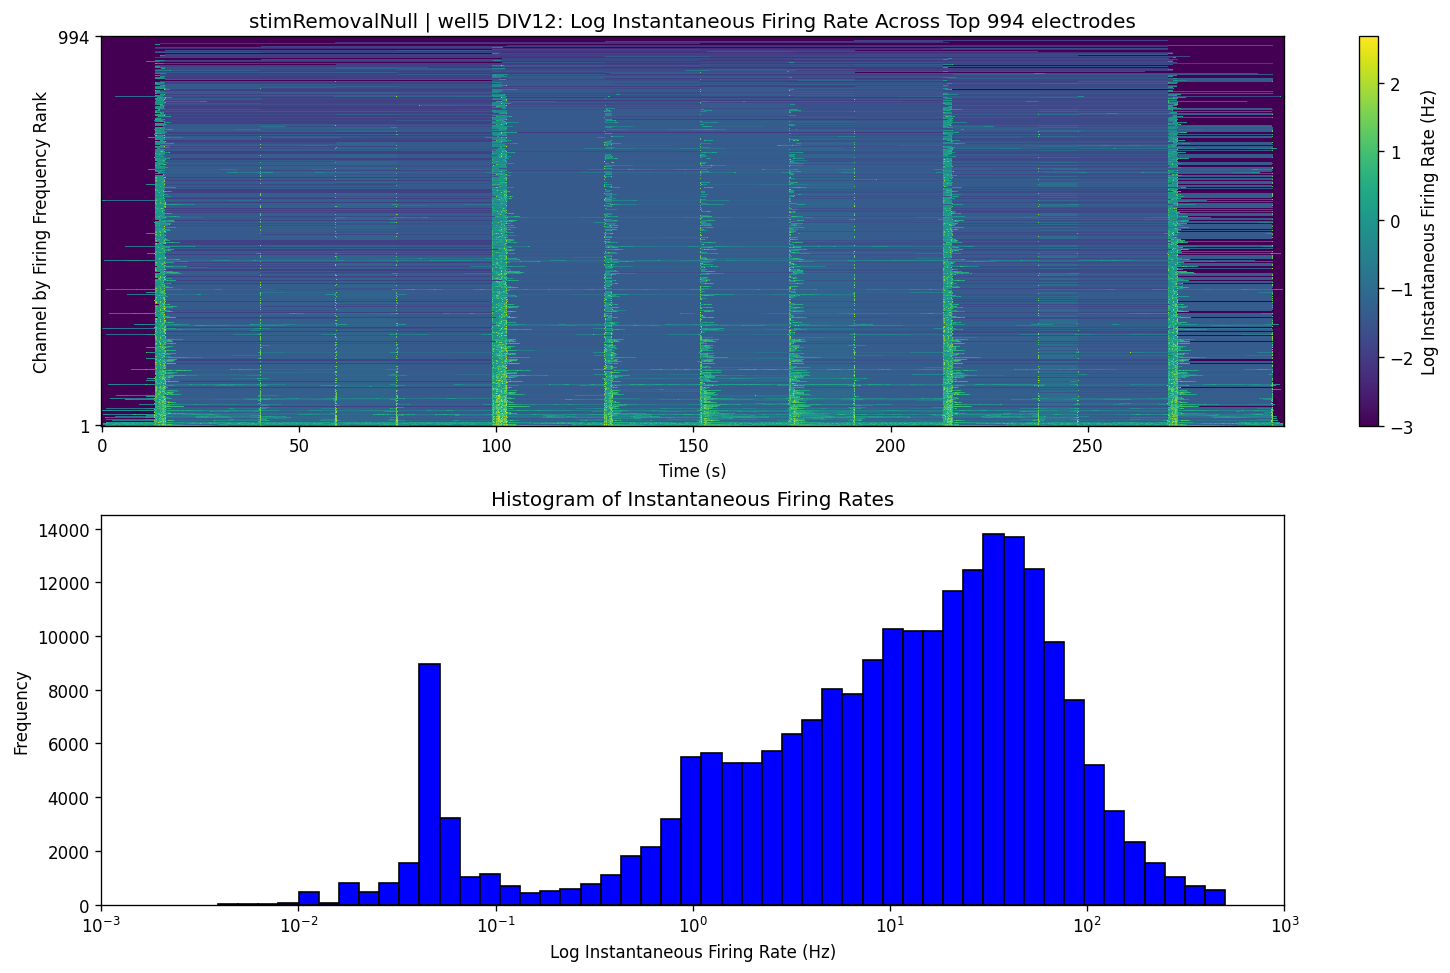

In [17]:
ifr_analyzer.plot_timeseries(title="stimRemovalNull", recording_titles=recording_labels)

## Distance-Dependent Firing Statistics

/Users/danielrebbin/Documents/GitHub/ephax/ephax/analyzers/firing_distance.py:134: OptimizeWarning: Covariance of the parameters could not be estimated
  exp_popt, _ = curve_fit(_exp_fun, x_valid, y_valid, p0=[A0, k0, C0], maxfev=10000)


KeyboardInterrupt: 

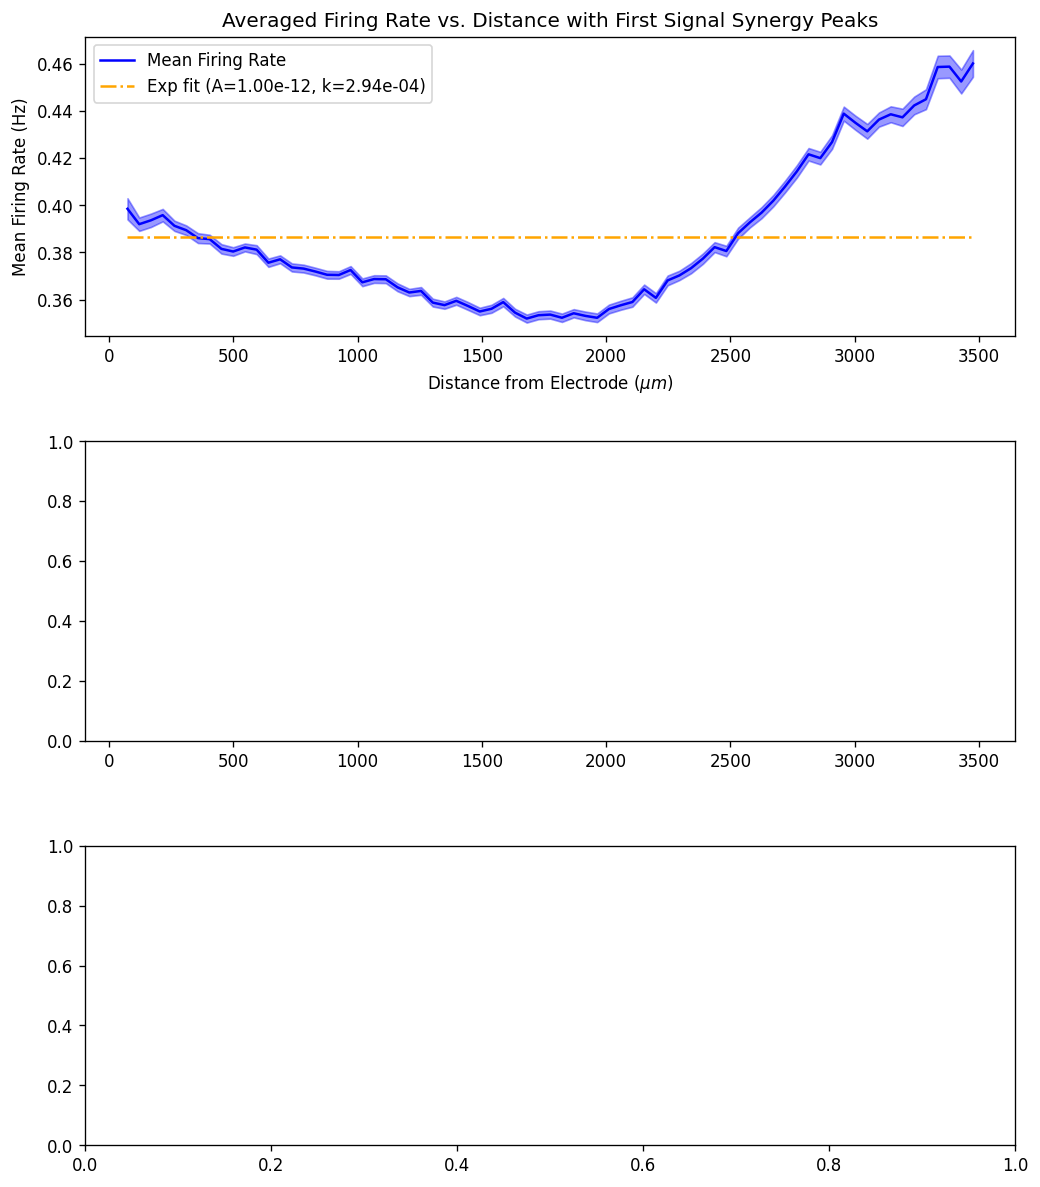

In [18]:
shuffle_layout_coordinates = True
permute_for_null = True
num_permutations = 2
perm_seed = 12345

perm_datasets = []
if permute_for_null:
    for perm_idx in range(num_permutations):
        permuted_recs = []
        for rec_idx, rec in enumerate(ds.recordings):
            seed = None if perm_seed is None else perm_seed + perm_idx * 1000 + rec_idx
            permuted_recs.append(
                rec.randomize_electrode_mapping(
                    seed=seed,
                    inplace=False,
                    shuffle_layout_coordinates=shuffle_layout_coordinates,
                )
            )
        perm_datasets.append(RestingActivityDataset(recordings=permuted_recs, sf=ds.sf))

fd_perm_dataset = perm_datasets[0] if perm_datasets else None
fd_analyzer = FiringDistanceAnalyzer(
    ds,
    dataset_perm=fd_perm_dataset,
    selection_prep_config=prep_cfg,
    ifr_config=ifr_cfg,
    v_eph=0.1,
    v_ax=0.45,
)

plusminus_ms = 2.0
rate_vs_distance = fd_analyzer.avg_rate_vs_distance()
fd_analyzer.plot_rate_with_synergy(rate_vs_distance, show_exponential_fit=True)

cof_res = fd_analyzer.cofiring_avg_vs_distance(plusminus_ms=plusminus_ms, log=False)
fd_analyzer.plot_cofiring_with_synergy(cof_res)


## Temporal Co-firing Heatmap

In [ ]:
cft_cfg = CofiringTemporalConfig(start_ms=-20, stop_ms=20, step_ms=1, normalize=False)
cft_analyzer = CofiringTemporalAnalyzer(ds, cft_cfg, selection_prep_config=prep_cfg)
cft_analyzer.plot_avg_cofiring_heatmap()


## Optional: Co-firing GIF

This can be slow on larger datasets.


In [ ]:
cfcfg = CofiringTemporalConfig(start_ms=-20, stop_ms=20, step_ms=4, normalize=False)
cfa = CofiringTemporalAnalyzer(ds, cfcfg, selection_prep_config=prep_cfg)

# cfa.plot_avg_cofiring_heatmap()
# cfa.create_theta_gif(output_filename="cofiring_theta_stimRemovalNull.gif")
cfa.create_grid_gif(output_filename="cofiring_grid_stimRemovalNull.gif")
display(Image(filename="cofiring_grid_stimRemovalNull.gif"))


## DCT Spatial Analysis

In [ ]:
dct_an = DCTAnalyzer(ds)
interp_grids = dct_an.compute_interpolated_grids(grid_size=50.0)

avg_dct = DCTAnalyzer.average_dct([g.grid for g in interp_grids])
recon = DCTAnalyzer.reconstruct_from_top_components(
    avg_dct,
    stop_rank=3,
    start_rank=0,
    plot_distribution=True,
)
DCTAnalyzer.plot_reconstructed_grid(reconstructed=recon, res=interp_grids[0])
DCTAnalyzer.extract_and_plot_spatial_frequencies_from_dct(
    avg_dct,
    n_components_stop=3,
    n_components_start=0,
    array_dims=(3800, 2100),
    axis="x",
)


## Per-Recording Distance Fits (Using Per-Recording IFR Peaks)

This section fits the distance-dependent firing model to each recording independently. 
For each recording, IFR peaks are inferred from that recording only and then used in the synergy overlay.


In [ ]:
from ephax import RestingActivityDataset

COFIRING_PM_MS = 2.0
per_recording_rows = []

for rec_idx, rec in enumerate(ds.recordings):
    meta = recording_metadata[rec_idx]
    print(f"\n=== {recording_labels[rec_idx]} ===")
    ds_i = RestingActivityDataset(recordings=[rec], sf=ds.sf)

    # Keep the same selection strategy as the pooled analysis
    refs_i = ds_i.select_ref_electrodes(prep_cfg)
    n_refs = int(refs_i[0].size) if refs_i and hasattr(refs_i[0], 'size') else 0

    # Infer IFR peaks for this recording only
    ifr_i = IFRAnalyzer.from_dataset(ds_i, config=ifr_cfg, selection_prep_config=prep_cfg)
    peaks_i = ifr_i.peaks()

    peak_hz = np.array([])
    weights = np.array([])
    try:
        fit_i = ifr_i.fit_gmm(peaks_i.values)
        peak_hz = np.asarray(fit_i.means_hz, dtype=float)
        weights = np.asarray(fit_i.weights, dtype=float)
    except Exception as exc:
        print(f"IFR GMM fit failed for recording {rec_idx}: {exc}")

    print(f"IFR samples: {peaks_i.values.size}; refs: {n_refs}")
    if peak_hz.size:
        print("IFR GMM peaks (Hz):", np.round(np.sort(peak_hz), 2))
    else:
        print("No IFR peaks available for synergy overlay.")

    # Distance-dependent firing fit for this recording
    fd_i = FiringDistanceAnalyzer(
        ds_i,
        selection_prep_config=prep_cfg,
        ifr_config=ifr_cfg,
        v_eph=0.1,
        v_ax=0.45,
    )

    rate_i = fd_i.avg_rate_vs_distance()
    n_rate_bins = int(rate_i.binned.centers.size)
    if n_rate_bins == 0:
        print("No valid rate-vs-distance bins for this recording; skipping rate plot.")
    else:
        fd_i.plot_rate_with_synergy(
            rate_i,
            title=f"Recording {rec_idx}: Firing Rate vs Distance + Synergy",
            show_exponential_fit=True,
        )

    # Distance-dependent co-firing fit for this recording
    cof_i = fd_i.cofiring_avg_vs_distance(plusminus_ms=COFIRING_PM_MS, log=False)
    n_cof_bins = int(cof_i.binned.centers.size)
    if n_cof_bins == 0:
        print("No valid cofiring-vs-distance bins for this recording; skipping cofiring plot.")
    else:
        fd_i.plot_cofiring_with_synergy(
            cof_i,
            show_exponential_fit=True,
        )

    per_recording_rows.append(
        {
            'recording_idx': rec_idx,
            'recording_id': meta['recording_id'],
            'culture_id': meta['culture_id'],
            'well': int(meta['well']),
            'div': int(meta['div']),
            'n_ifr_samples': int(peaks_i.values.size),
            'n_refs': n_refs,
            'n_gmm_peaks': int(peak_hz.size),
            'gmm_peaks_hz': np.round(np.sort(peak_hz), 3).tolist(),
            'gmm_weights': np.round(weights, 4).tolist(),
            'n_rate_bins': n_rate_bins,
            'n_cofiring_bins': n_cof_bins,
        }
    )

per_recording_summary = pd.DataFrame(per_recording_rows)
aggregate_fit_summary = (
    per_recording_summary
    .groupby("div", as_index=False)
    .agg(
        n_recordings=("recording_idx", "count"),
        n_wells=("well", "nunique"),
        mean_ifr_samples=("n_ifr_samples", "mean"),
        mean_refs=("n_refs", "mean"),
        mean_gmm_peaks=("n_gmm_peaks", "mean"),
        mean_rate_bins=("n_rate_bins", "mean"),
        mean_cofiring_bins=("n_cofiring_bins", "mean"),
    )
)
display(per_recording_summary)
display(aggregate_fit_summary.round(3))
